# Đánh giá mô hình với K-Fold Cross Validation & Stacking Ensemble
Notebook này thực hiện 5-Fold CV cho từng mô hình con (Base Models) và mô hình tổng (Stacking) để đánh giá độ ổn định, so sánh hiệu năng, và kiểm tra hiện tượng rò rỉ dữ liệu (Data Leakage).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate, KFold, GroupKFold
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Import thư viện thành công!')

Import thư viện thành công!


In [2]:
# Load Dữ liệu đã tiền xử lý hoàn chỉnh
df = pd.read_csv('Agri_Data_Preprocessed.csv')
df.head()
TARGET = 'NDVI_Season_Mean'
X = df.drop(columns=[TARGET])

# Safety: ep kieu tat ca cot object ve float (phong truong hop Target Encoding chua chay)
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category').cat.codes.astype(float)
    print(f'Da ep kieu cot {col} tu object sang float')
y = df[TARGET]

print(f'Feature columns: {X.shape[1]} | Target: {TARGET}')

Feature columns: 19 | Target: NDVI_Season_Mean


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4608 entries, 0 to 4607
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Avg_Salinity_Index                         4608 non-null   float64
 1   Rainfall                                   4608 non-null   float64
 2   Wind_Mean                                  4608 non-null   float64
 3   Wind_Max                                   4608 non-null   float64
 4   Temp_Max                                   4608 non-null   float64
 5   District                                   4608 non-null   float64
 6   Clay                                       4608 non-null   float64
 7   Nitrogen                                   4608 non-null   float64
 8   Soil_Moisture_mm                           4608 non-null   float64
 9   pH                                         4608 non-null   float64
 10  AP_Ratio                

In [4]:
# Khai báo các mô hình Base và Meta
models = {
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE, n_estimators=500, learning_rate=0.05, max_depth=6),
    'LightGBM': lgb.LGBMRegressor(random_state=RANDOM_STATE, n_estimators=500, learning_rate=0.05, max_depth=6, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, iterations=500, learning_rate=0.05, depth=6, verbose=0),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200, max_depth=10)
}

# Khai báo Stacking
estimators = [(name, model) for name, model in models.items()]
models['Stacking (Ridge)'] = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)


In [5]:
# Cấu hình K-Fold và Metrics đánh giá
kf = GroupKFold(n_splits=5)
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error'
}

results_list = []

print("Bắt đầu 5-Fold Cross Validation cho từng mô hình...")
for name, model in models.items():
    print(f"Đang chạy CV cho {name}...")
    # Dùng n_jobs=1 hoặc n_jobs=-1 (nếu chạy local có nhiều core) để tăng tốc độ
    cv_results = cross_validate(model, X, y, cv=kf, groups=df['District'], scoring=scoring, return_train_score=True, n_jobs=1)
    
    results_list.append({
        'Model': name,
        'Train R2': np.mean(cv_results['train_r2']),
        'Val R2': np.mean(cv_results['test_r2']),
        'Val MAE': -np.mean(cv_results['test_mae']),
        'Val MSE': -np.mean(cv_results['test_mse']),
        'Val RMSE': -np.mean(cv_results['test_rmse'])
    })

results_df = pd.DataFrame(results_list)
display(results_df.round(4))

Bắt đầu 5-Fold Cross Validation cho từng mô hình...
Đang chạy CV cho XGBoost...
Đang chạy CV cho LightGBM...
Đang chạy CV cho CatBoost...
Đang chạy CV cho RandomForest...
Đang chạy CV cho Stacking (Ridge)...


,Model,Train R2,Val R2,Val MAE,Val MSE,Val RMSE
0,XGBoost,1.0000,0.8313,0.0315,0.0019,0.0431
1,LightGBM,1.0000,0.8320,0.0303,0.0019,0.0431
2,CatBoost,1.0000,0.8642,0.0282,0.0016,0.0390
3,RandomForest,0.9999,0.8619,0.0298,0.0015,0.0384
4,Stacking (Ridge),0.9963,0.8804,0.0268,0.0014,0.0362


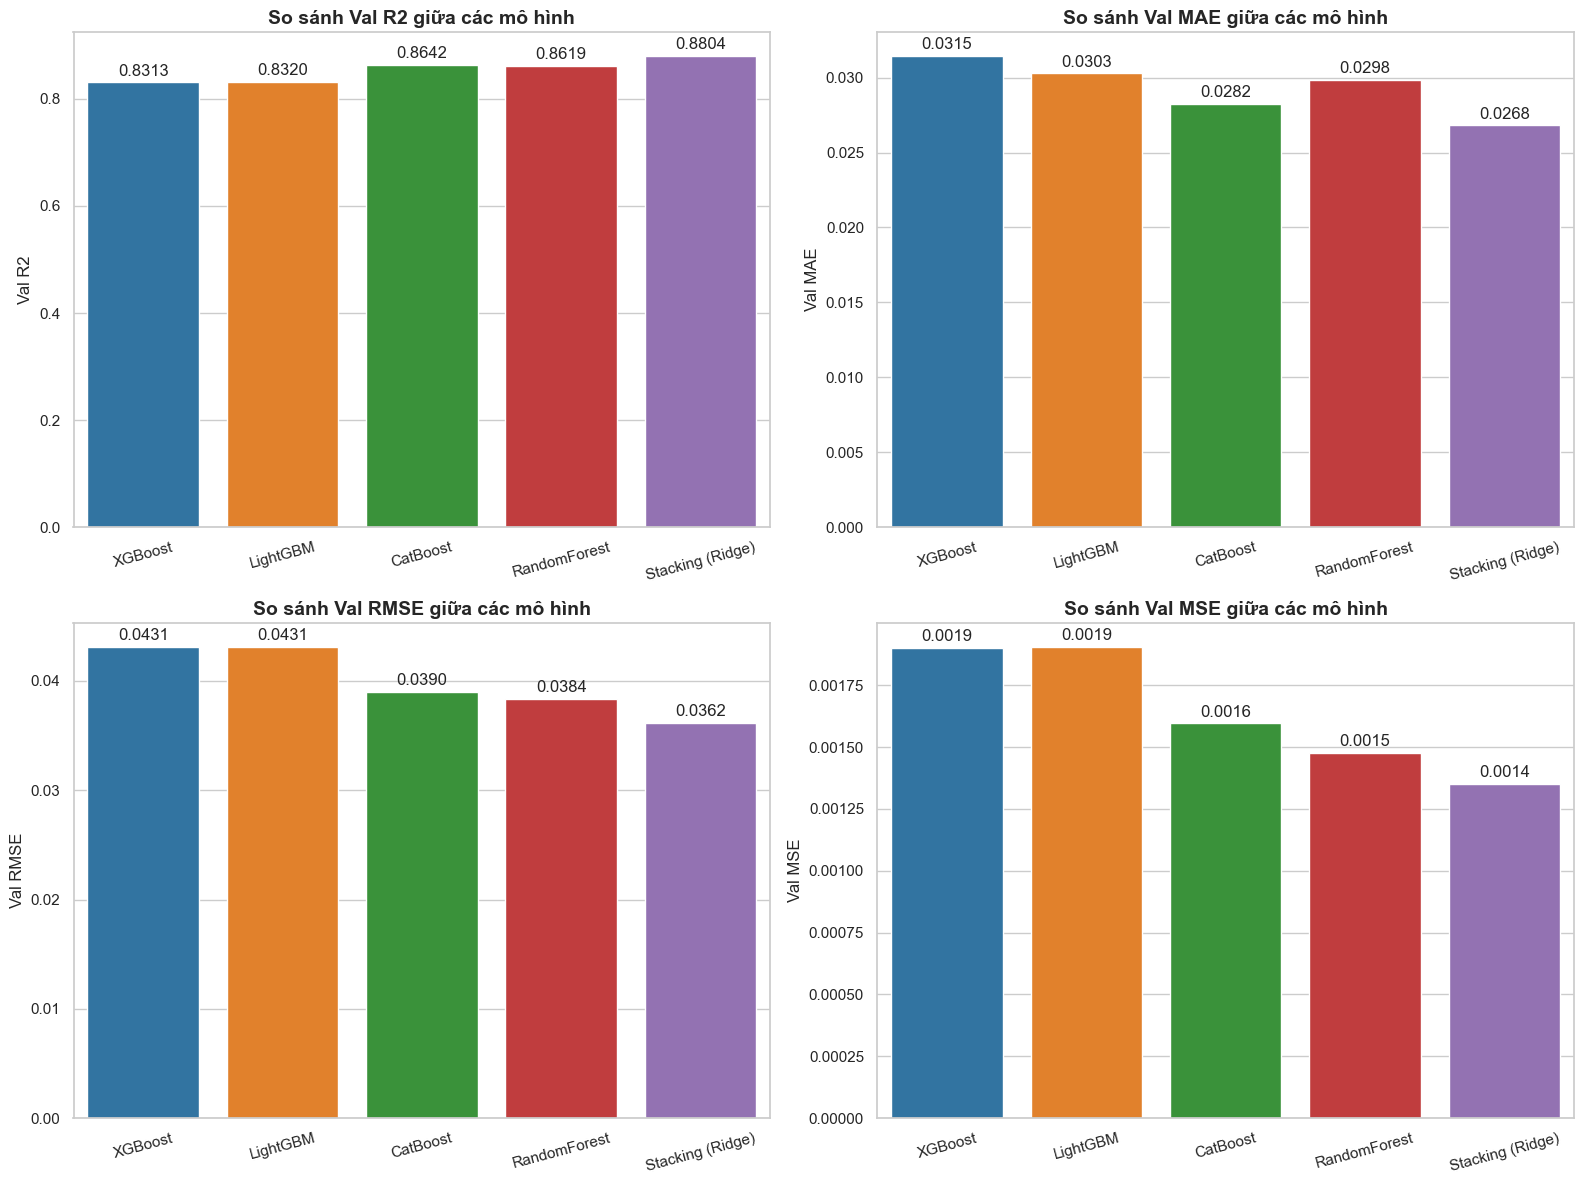

In [7]:
# VẼ BIỂU ĐỒ SO SÁNH 4 METRICS GIỮA CÁC MÔ HÌNH
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics_to_plot = ['Val R2', 'Val MAE', 'Val RMSE', 'Val MSE']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Màu cuối dành cho Stacking

for i, metric in enumerate(metrics_to_plot):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    
    sns.barplot(x='Model', y=metric, data=results_df, ax=ax, palette=colors)
    ax.set_title(f'So sánh {metric} giữa các mô hình', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    
    # Thêm giá trị số lên đầu mỗi cột bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import cross_val_predict

print('Đang xuất file dự đoán (Out-of-Fold Predictions) bằng mô hình Stacking...')
best_model = models['Stacking (Ridge)']

# Dùng cross_val_predict để lấy dự đoán của tập Test (khi model không hề thấy data đó)
predictions = cross_val_predict(best_model, X, y, cv=kf, groups=df['District'], n_jobs=-1)

# Tạo DataFrame chứa kết quả
pred_df = pd.DataFrame({
    'Actual_NDVI': y,
    'Predicted_NDVI': predictions,
    'Error_Value': y - predictions
})

# Thêm các cột quan trọng từ dataset ban đầu (nếu còn) để dễ đối chiếu
if 'District' in df.columns:
    pred_df['District_Encoded'] = df['District']
if 'Season' in df.columns:
    pred_df['Season'] = df['Season']
    
# Lưu ra file CSV
pred_df.to_csv('predictions.csv', index=False, encoding='utf-8-sig')
print(' Đã lưu thành công file predictions.csv!')
pred_df.head(10)

Đang xuất file dự đoán (Out-of-Fold Predictions) bằng mô hình Stacking...
 Đã lưu thành công file predictions.csv!


,Actual_NDVI,Predicted_NDVI,Error_Value,District_Encoded
0,0.511809,0.541734,-0.029924,0.428702
1,0.511809,0.541734,-0.029924,0.428702
2,0.511809,0.541734,-0.029924,0.428702
3,0.511809,0.541734,-0.029924,0.428702
4,0.267147,0.336832,-0.069685,0.428702
5,0.267147,0.336832,-0.069685,0.428702
6,0.267147,0.336832,-0.069685,0.428702
7,0.267147,0.336832,-0.069685,0.428702
8,0.511809,0.541734,-0.029924,0.428702
9,0.507816,0.541666,-0.033850,0.428702
